In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving customer_segmentation_kmeans_dataset.csv to customer_segmentation_kmeans_dataset (26).csv


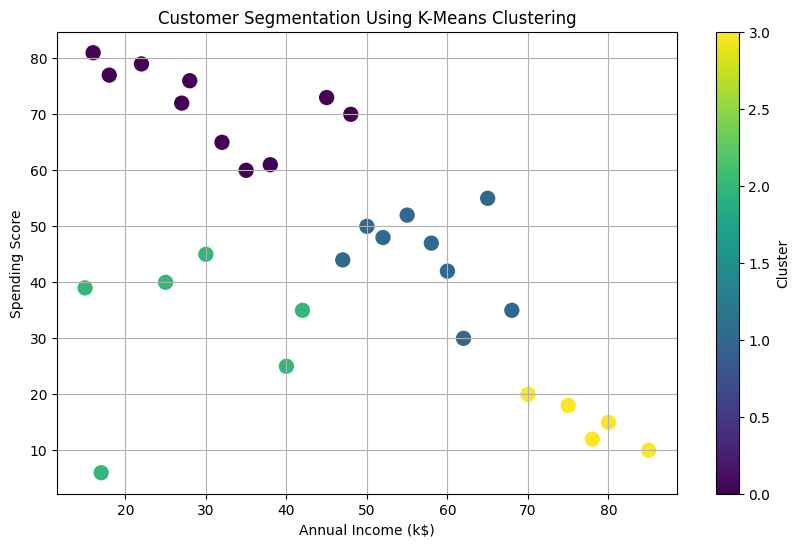

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("customer_segmented_results.csv")

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Annual_Income_k"],
    df["Spending_Score"],
    c=df["Cluster"],
    s=100
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation Using K-Means Clustering")
plt.grid(True)
plt.colorbar(label="Cluster")

plt.show()

In [ ]:
# Display customer segmentation results

# Check whether the Cluster column exists
if "Cluster" not in df.columns:
    print("Cluster column not found. Applying K-Means again...")

    # Select features
    X = df[["Annual_Income_k", "Spending_Score"]]

    # Standardize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply K-Means
    kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
    df["Cluster"] = kmeans.fit_predict(X_scaled)

# Display the first 10 customers
print("Customer Segmentation Results:")
display(df.head(10))

# Display number of customers in each cluster
print("\nNumber of Customers in Each Cluster:")
print(df["Cluster"].value_counts().sort_index())

Customer Segmentation Results:


,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster
0,1,19,15,39,2
1,2,21,16,81,0
2,3,20,17,6,2
3,4,23,18,77,0
4,5,31,25,40,2
5,6,35,28,76,0
6,7,40,30,45,2
7,8,28,35,60,0
8,9,29,38,61,0
9,10,42,40,25,2



Number of Customers in Each Cluster:
Cluster
0    10
1     9
2     6
3     5
Name: count, dtype: int64


In [ ]:


print("Customer Segmentation Results:")
display(df.head(10))

print("\nNumber of Customers in Each Cluster:")
print(df["Cluster"].value_counts().sort_index())

Customer Segmentation Results:


,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster
0,1,19,15,39,2
1,2,21,16,81,0
2,3,20,17,6,2
3,4,23,18,77,0
4,5,31,25,40,2
5,6,35,28,76,0
6,7,40,30,45,2
7,8,28,35,60,0
8,9,29,38,61,0
9,10,42,40,25,2



Number of Customers in Each Cluster:
Cluster
0    10
1     9
2     6
3     5
Name: count, dtype: int64


In [ ]:
df.head(10)

,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster
0,1,19,15,39,2
1,2,21,16,81,0
2,3,20,17,6,2
3,4,23,18,77,0
4,5,31,25,40,2
5,6,35,28,76,0
6,7,40,30,45,2
7,8,28,35,60,0
8,9,29,38,61,0
9,10,42,40,25,2


In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed successfully!")

K-Means clustering completed successfully!


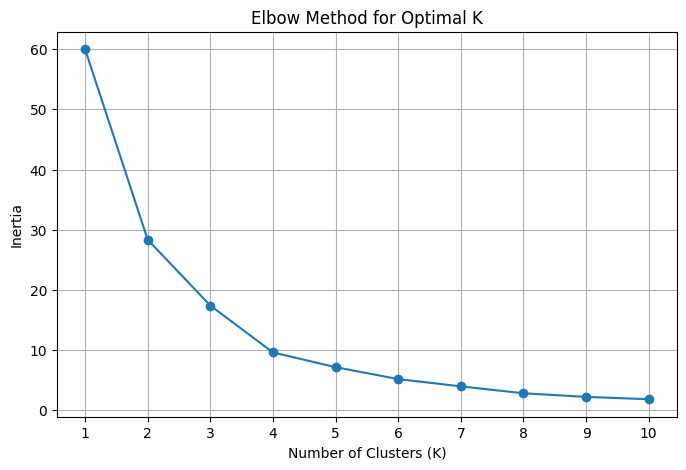

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Standardization completed successfully!")

Standardization completed successfully!


In [ ]:

X = df[["Annual_Income_k", "Spending_Score"]]

X.head()

,Annual_Income_k,Spending_Score
0,15,39
1,16,81
2,17,6
3,18,77
4,25,40


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID         0
Age                0
Annual_Income_k    0
Spending_Score     0
Cluster            0
dtype: int64


In [ ]:
df.describe()

,CustomerID,Age,Annual_Income_k,Spending_Score,Cluster
count,30.000000,30.000000,30.000000,30.000000,30.000000
mean,15.500000,34.900000,46.100000,46.066667,1.200000
std,8.803408,10.554783,20.823313,22.432940,1.095445
min,1.000000,19.000000,15.000000,6.000000,0.000000
25%,8.250000,26.250000,28.500000,31.250000,0.000000
50%,15.500000,33.500000,46.000000,46.000000,1.000000
75%,22.750000,43.500000,61.500000,64.000000,2.000000
max,30.000000,55.000000,85.000000,81.000000,3.000000


In [ ]:
print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (30, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   CustomerID       30 non-null     int64
 1   Age              30 non-null     int64
 2   Annual_Income_k  30 non-null     int64
 3   Spending_Score   30 non-null     int64
 4   Cluster          30 non-null     int32
dtypes: int32(1), int64(4)
memory usage: 1.2 KB


In [ ]:
df = pd.read_csv("customer_segmentation_kmeans_dataset.csv")

df.head()

,CustomerID,Age,Annual_Income_k,Spending_Score
0,1,19,15,39
1,2,21,16,81
2,3,20,17,6
3,4,23,18,77
4,5,31,25,40
